# Import libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data preprocessing

Loading dataset and preprocessing

In [18]:
# Load dataset
df = pd.read_csv("/content/drive/My Drive/Quant Analyst/prometheus_quant_assignment_hf_data.csv")

In [19]:
# Before cleaning
shape = df.shape
print(f"The dataset has {shape[0]} rows and {shape[1]} columns.")

The dataset has 234600 rows and 4 columns.


In [20]:
# Remove Nan, zero price or time duplicates
df = df.sort_values(["symbol", "timestamp"])
df = df.dropna(subset=["price", "timestamp"])
df = df[df["price"] > 0]
df = df.drop_duplicates(subset=["symbol", "timestamp"])

# Only keep the fifth observation
df = df.sort_values(["symbol", "timestamp"])
df = df[df.groupby("symbol").cumcount() % 5 == 4]

In [21]:
# After cleaning
shape = df.shape
print(f"The dataset has {shape[0]} rows and {shape[1]} columns.")

The dataset has 46920 rows and 4 columns.


In [22]:
# Descriptive statistics of price by symbol after cleaning
descriptive_stats = (df.groupby("symbol")["price"].agg(["count", "mean", "std", "min", "median", "max"]))

print(descriptive_stats)

        count        mean       std        min      median         max
symbol                                                                
STK_A    9384  100.007436  1.295443  96.208480  100.055691  102.544201
STK_B    9384  100.171840  1.169689  97.371157  100.293820  102.403458
STK_C    9384   98.404522  1.197581  96.106006   98.650352  100.682983
STK_D    9384   96.980004  2.642122  91.196990   97.148276  101.797286
STK_E    9384  100.957852  2.222611  96.827643  101.074875  104.538473


Price graph

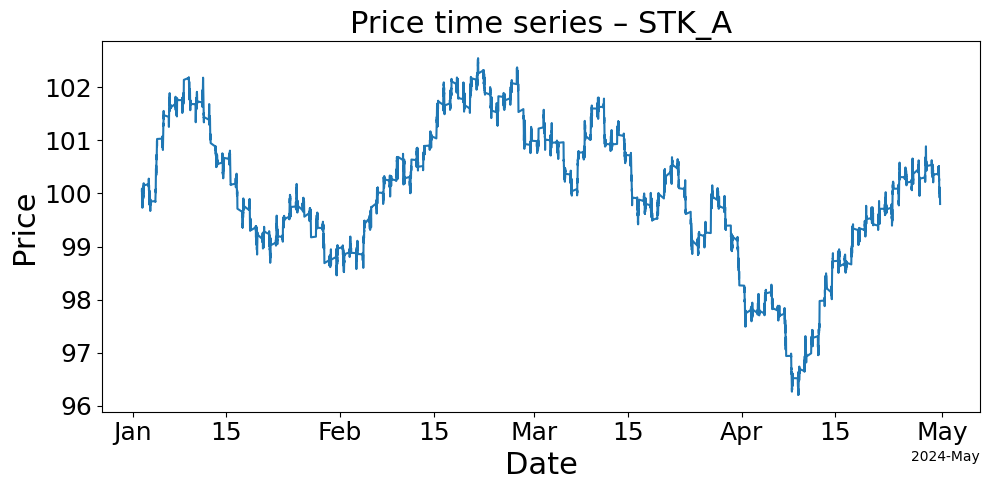

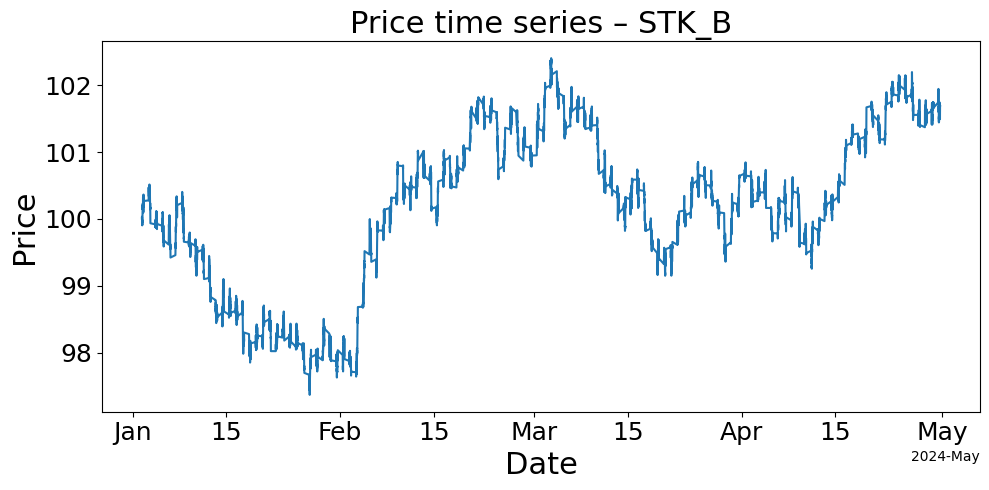

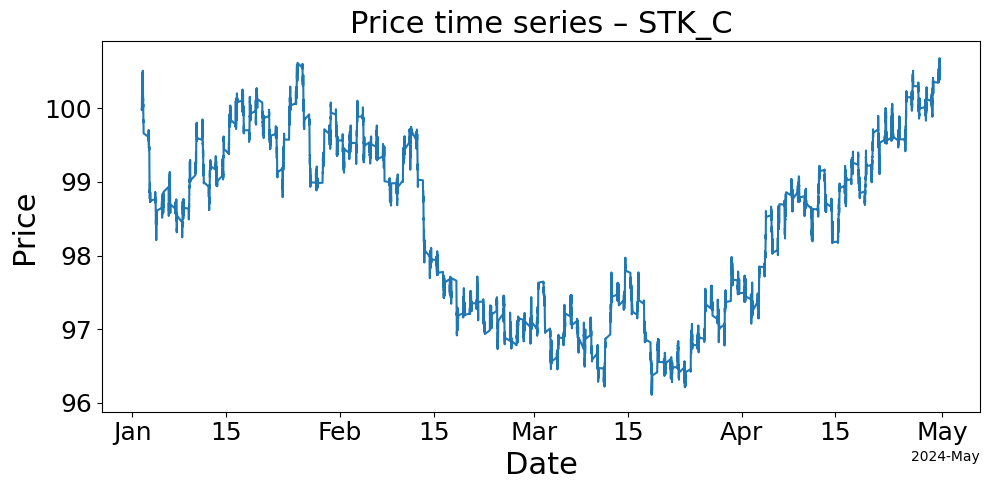

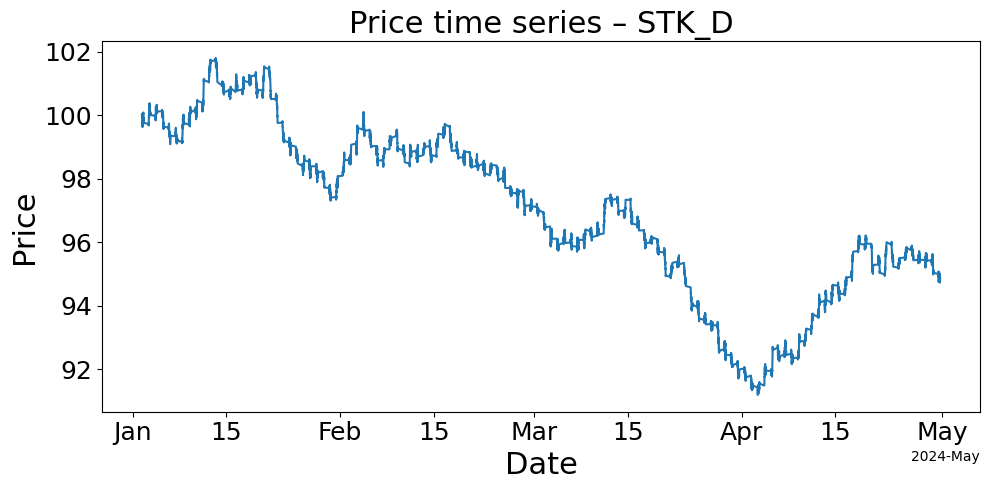

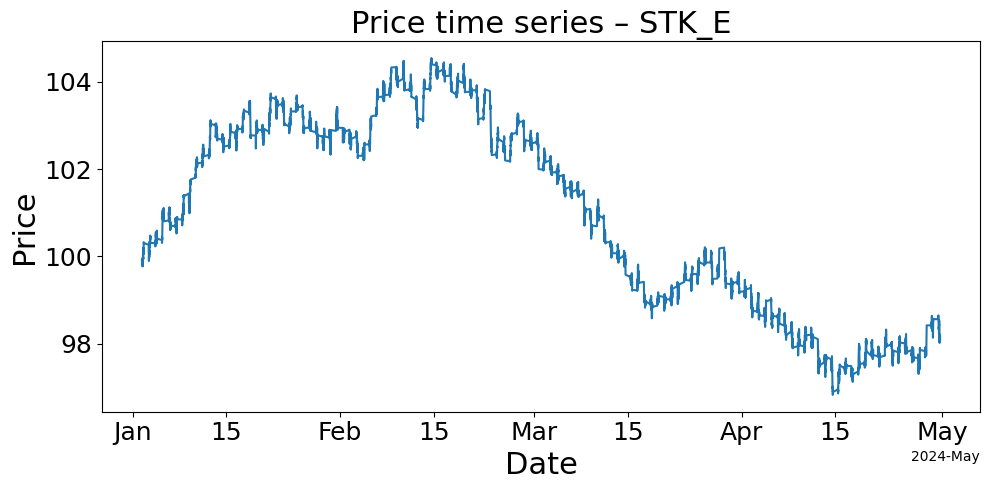

In [23]:
# Plot price time series by symbol
df["timestamp"] = pd.to_datetime(df["timestamp"])

for symbol, data in df.groupby("symbol"):

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(data["timestamp"], data["price"], linewidth=1.5)
    ax.set_title(f"Price time series – {symbol}", fontsize=22)
    ax.set_xlabel("Date", fontsize=22)
    ax.set_ylabel("Price", fontsize=22)
    ax.tick_params(axis="both", labelsize=18)
    locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.show()

Setting up RV

In [24]:
# Prep
df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["symbol", "timestamp"])

# 5-minute log returns per symbol, within each trading day
df["date"] = df["timestamp"].dt.normalize()
df["log_price"] = np.log(df["price"])
df["r"] = df.groupby(["symbol", "date"])["log_price"].diff()
ret = df.dropna(subset=["r"]).copy()

# Daily RV
ret["r2"] = ret["r"] ** 2
daily_rv = (
    ret.groupby(["symbol", "date"], as_index=False)["r2"]
       .sum()
       .rename(columns={"r2": "RV_daily"}))

daily_rv = daily_rv.sort_values(["symbol", "date"])
daily_rv["RV_d_lag"] = daily_rv.groupby("symbol")["RV_daily"].shift(1)

# Weekly RV, t-2; t-5
daily_rv["RV_weekly"] = (
    daily_rv.groupby("symbol")["RV_daily"]
            .transform(lambda s: s.shift(2).rolling(4).mean()))

daily_rv = daily_rv.sort_values(["symbol", "date"])
daily_rv["RV_w_lag"] = daily_rv.groupby("symbol")["RV_weekly"].shift(1)

# Monthly RV, t-6; t-22
daily_rv["RV_monthly"] = (
    daily_rv.groupby("symbol")["RV_daily"]
            .transform(lambda s: s.shift(6).rolling(17).mean())
)

daily_rv = daily_rv.sort_values(["symbol", "date"])
daily_rv["RV_m_lag"] = daily_rv.groupby("symbol")["RV_monthly"].shift(1)

# Realised volatility
daily_rv["volatility_daily"] = np.sqrt(daily_rv["RV_daily"])
daily_rv["volatility_weekly"] = np.sqrt(daily_rv["RV_weekly"])
daily_rv["volatility_monthly"] = np.sqrt(daily_rv["RV_monthly"])

Volatility graph

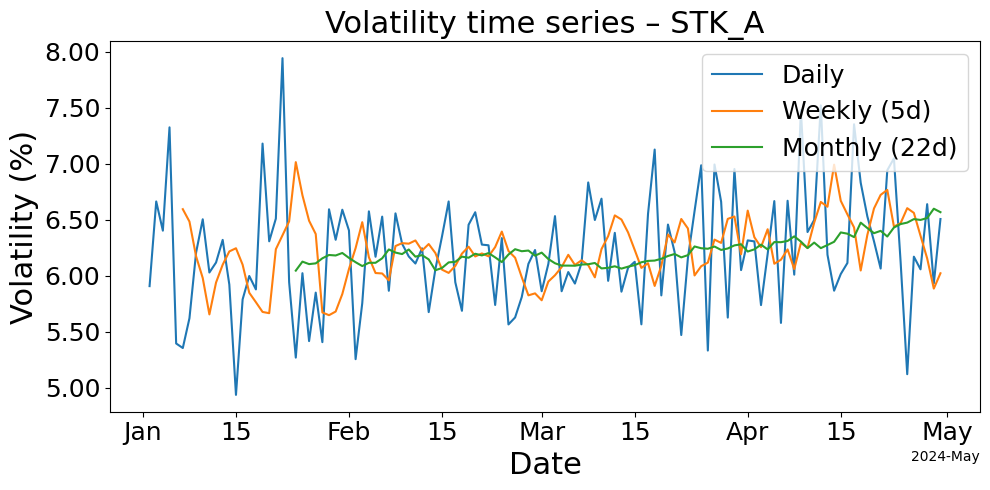

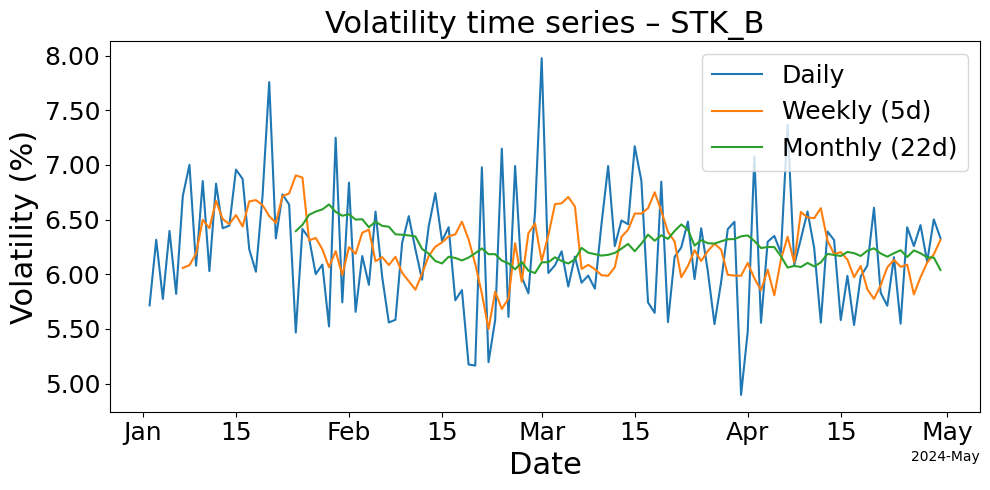

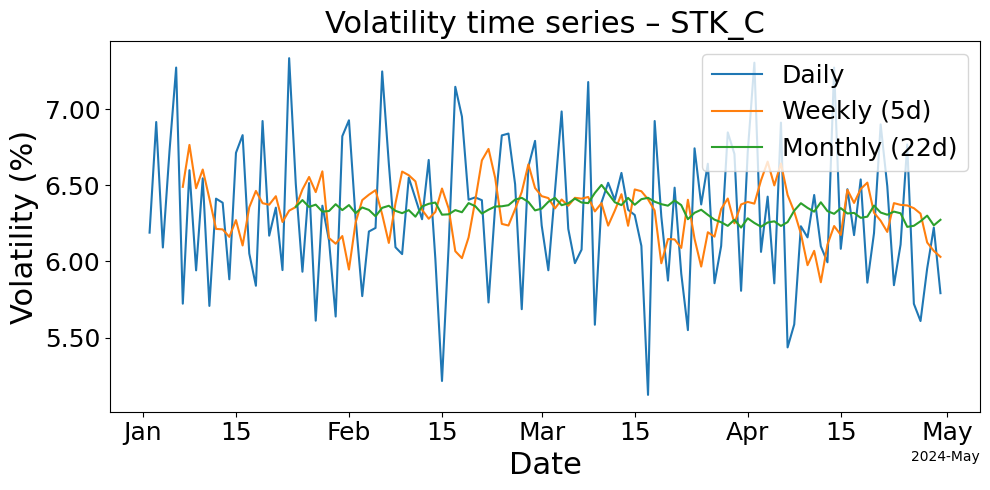

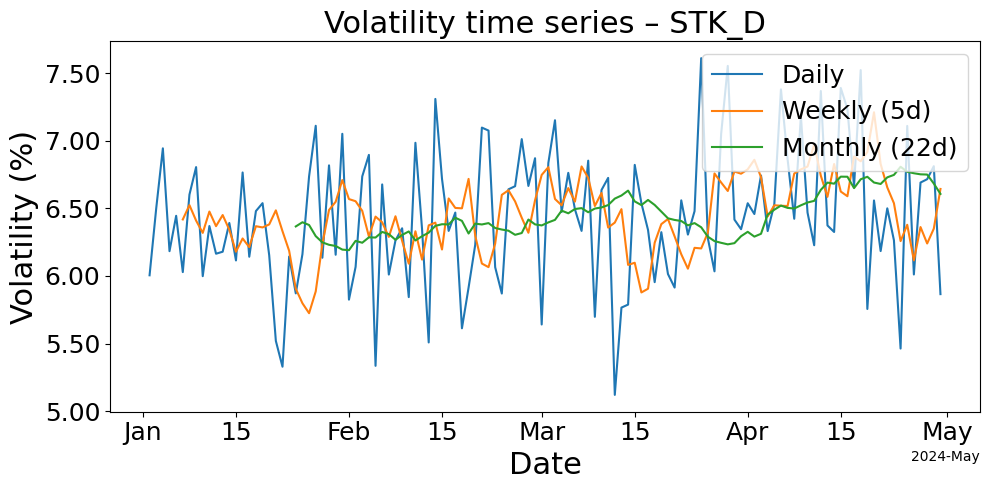

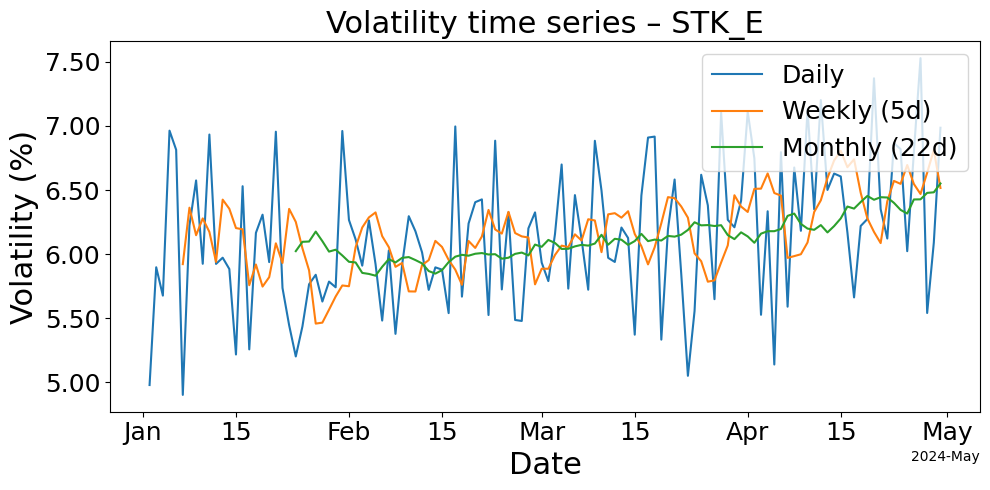

In [25]:
# Plot daily, weekly, monthly volatility in percent by symbol (annualised)
daily_rv["volatility_daily_pct"] = 100 * (daily_rv["volatility_daily"]) * np.sqrt(252)
daily_rv["volatility_weekly_pct"] = 100 * (daily_rv["volatility_weekly"]) * np.sqrt(252)
daily_rv["volatility_monthly_pct"] = 100 * (daily_rv["volatility_monthly"]) * np.sqrt(252)

for sym in daily_rv["symbol"].unique():
    sub = daily_rv[daily_rv["symbol"] == sym].sort_values("date")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(sub["date"], sub["volatility_daily_pct"], label="Daily")
    ax.plot(sub["date"], sub["volatility_weekly_pct"], label="Weekly (5d)")
    ax.plot(sub["date"], sub["volatility_monthly_pct"], label="Monthly (22d)")
    ax.set_title(f"Volatility time series – {sym}", fontsize=22)
    ax.set_xlabel("Date", fontsize=22)
    ax.set_ylabel("Volatility (%)", fontsize=22)
    ax.tick_params(axis="both", labelsize=18)
    locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.legend(loc="upper right", fontsize=18)

    plt.tight_layout()
    plt.show()

In [26]:
# Descriptive statistics for realised volatility by symbol
descriptive_stats_volatility = (daily_rv.groupby("symbol")[["volatility_daily_pct", "volatility_weekly_pct", "volatility_monthly_pct"]].agg(["count", "mean", "std", "min", "median", "max"]).round(2))

print(descriptive_stats_volatility)

       volatility_daily_pct                                 \
                      count  mean   std   min median   max   
symbol                                                       
STK_A                   120  6.21  0.52  4.94   6.17  7.94   
STK_B                   120  6.22  0.53  4.90   6.23  7.98   
STK_C                   120  6.31  0.46  5.12   6.30  7.33   
STK_D                   120  6.43  0.50  5.12   6.43  7.61   
STK_E                   120  6.15  0.56  4.90   6.16  7.53   

       volatility_weekly_pct                                 \
                       count  mean   std   min median   max   
symbol                                                        
STK_A                    115  6.23  0.28  5.65   6.23  7.02   
STK_B                    115  6.24  0.28  5.50   6.20  6.90   
STK_C                    115  6.34  0.18  5.86   6.36  6.76   
STK_D                    115  6.45  0.27  5.72   6.44  7.21   
STK_E                    115  6.16  0.29  5.46   6.15  6.81   

# Approach

Unit root test RV

In [27]:
# Check for stationarity with adf test
print("p-value for daily RV:", adfuller(daily_rv["volatility_daily"].dropna().values)[1])
print("p-value for weekly RV:", adfuller(daily_rv["volatility_weekly"].dropna().values)[1])
print("p-value for monthly RV:", adfuller(daily_rv["volatility_monthly"].dropna().values)[1])

p-value for daily RV: 0.0001189842362328883
p-value for weekly RV: 0.0002973278205104719
p-value for monthly RV: 0.023154924728935742


HAR-RV

In [28]:
# Prep
daily_rv = daily_rv.copy()
daily_rv["date"] = pd.to_datetime(daily_rv["date"])
daily_rv = daily_rv.sort_values(["symbol", "date"])

# Regressors
X_cols = ["RV_d_lag", "RV_w_lag", "RV_m_lag"]
y_col = "RV_daily"

har_data = daily_rv.dropna(subset=X_cols + [y_col]).copy()

# Define forecasting trading days
may_start = pd.Timestamp("2024-05-01")
may_end = pd.Timestamp("2024-05-31")
may_days = pd.bdate_range(may_start, may_end, freq="B")

# Fit the HAR-RV model per symbol
forecasts = []

for sym in har_data["symbol"].dropna().unique():
    hist = har_data[har_data["symbol"] == sym].sort_values("date").copy()

    if hist.empty:
        continue

    y_train = hist[y_col]
    X_train = sm.add_constant(hist[X_cols])
    model = sm.OLS(y_train, X_train).fit()

    rv_hist = hist[["date", "RV_daily"]].copy()

    # 3) Walk forward (May forecast)
    for d in may_days:
        last_date = d - pd.Timedelta(days=1)

        past = rv_hist[rv_hist["date"] <= last_date].sort_values("date").copy()

        if len(past) < 22:
            continue

        rv_d_lag = past["RV_daily"].iloc[-1]
        rv_w_lag = past["RV_daily"].iloc[-5:].mean()
        rv_m_lag = past["RV_daily"].iloc[-22:].mean()

        X_new = pd.DataFrame({"const": [1.0], "RV_d_lag": [rv_d_lag], "RV_w_lag": [rv_w_lag], "RV_m_lag": [rv_m_lag]})

        rv_hat = float(model.predict(X_new).iloc[0])
        rv_hat = max(rv_hat, 0.0)

        # 4) Convert to volatility forecast
        vol_hat = np.sqrt(rv_hat)

        forecasts.append({
                "symbol": sym,
                "date": d,
                "RV_daily_hat": rv_hat,
                "vol_daily_hat": vol_hat,
                "RV_d_lag_used": rv_d_lag,
                "RV_w_lag_used": rv_w_lag,
                "RV_m_lag_used": rv_m_lag,})

        rv_hist = pd.concat([rv_hist, pd.DataFrame({"date": [d], "RV_daily": [rv_hat]})],ignore_index=True)

forecast_may = pd.DataFrame(forecasts).sort_values(["symbol", "date"]).reset_index(drop=True)

Plot forecast

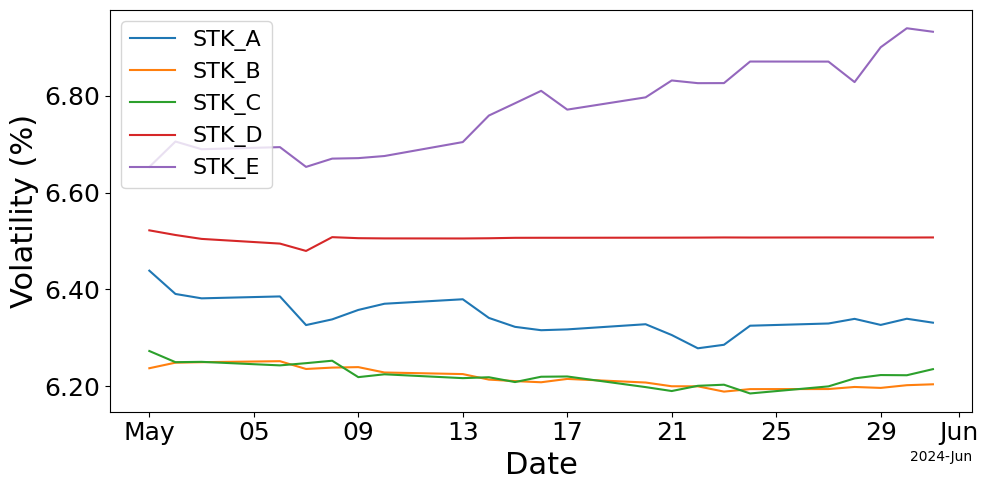

In [29]:
# Plot forecasted volatility in percent (all symbols in one graph and annualised)
forecast_may = forecast_may.copy()
forecast_may["vol_daily_hat_pct"] = 100 * forecast_may["vol_daily_hat"] * np.sqrt(252)

fig, ax = plt.subplots(figsize=(10, 5))

for sym in forecast_may["symbol"].unique():
    sub = forecast_may[forecast_may["symbol"] == sym].sort_values("date")
    ax.plot(sub["date"], sub["vol_daily_hat_pct"], label=sym)

ax.set_xlabel("Date", fontsize=22)
ax.set_ylabel("Volatility (%)", fontsize=22)
ax.tick_params(axis="both", labelsize=18)

locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

ax.legend(fontsize=16)
plt.tight_layout()
plt.show()

Summary statistics for forecasted volatility

In [30]:
# Descriptive statistics for forecasted realised volatility by symbol
forecast_may_stats = (forecast_may.groupby("symbol")["vol_daily_hat_pct"].agg(["count", "mean", "std", "min", "median", "max"]).round(2))

print(forecast_may_stats)

        count  mean   std   min  median   max
symbol                                       
STK_A      23  6.34  0.04  6.28    6.33  6.44
STK_B      23  6.22  0.02  6.19    6.21  6.25
STK_C      23  6.22  0.02  6.18    6.22  6.27
STK_D      23  6.51  0.01  6.48    6.51  6.52
STK_E      23  6.78  0.09  6.65    6.78  6.94


# Sanity check

Plot forecast + realised volatility of training

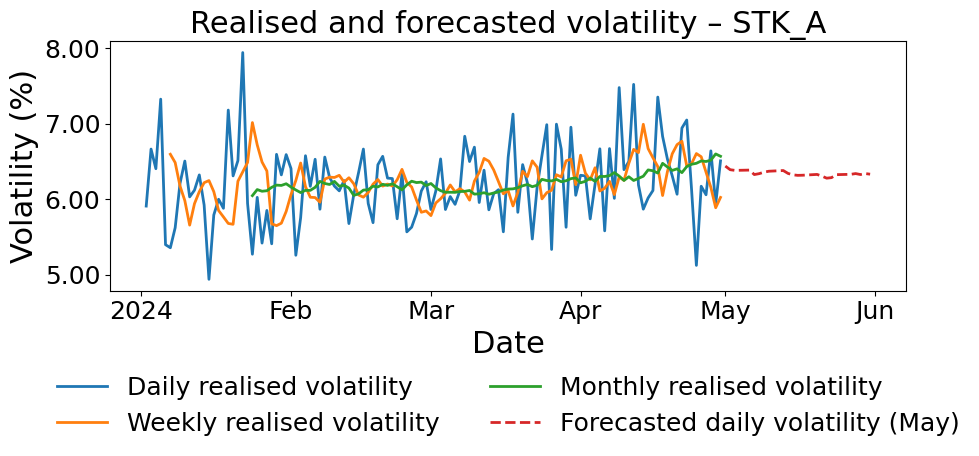

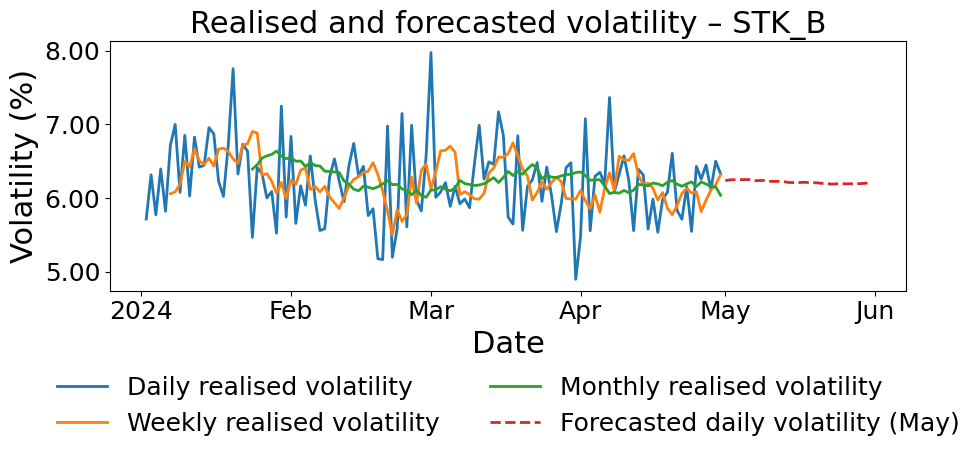

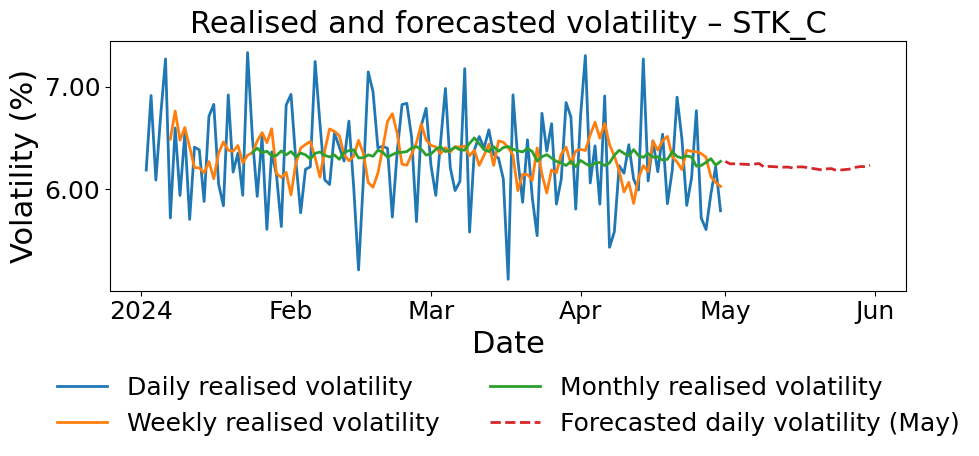

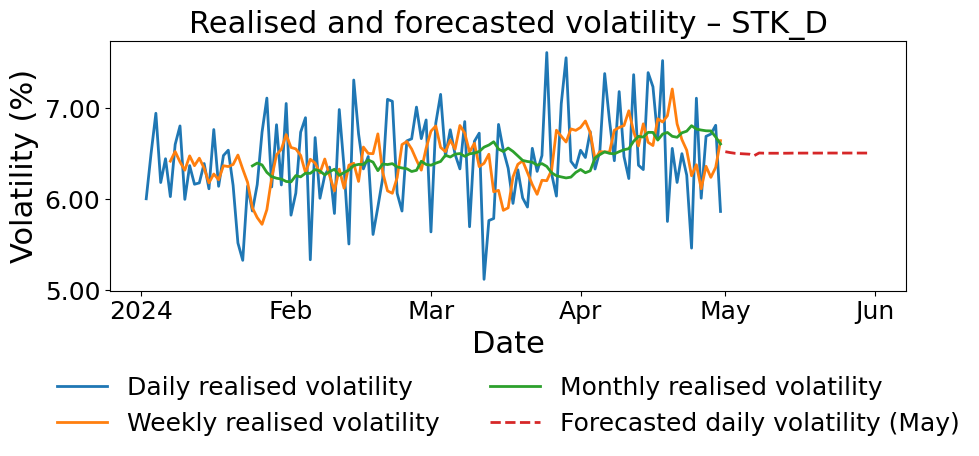

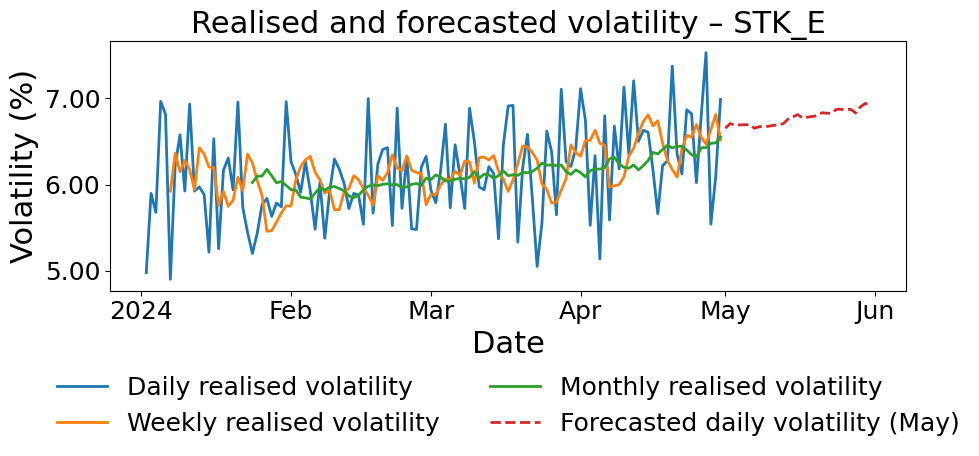

In [31]:
for sym in daily_rv["symbol"].unique():

    # Training (realised)
    train_sub = (
        daily_rv[daily_rv["symbol"] == sym]
        .sort_values("date"))

    # Forecast (May)
    forecast_sub = (
        forecast_may[forecast_may["symbol"] == sym]
        .sort_values("date"))

    fig, ax = plt.subplots(figsize=(10, 5))

    # Realised volatility
    ax.plot(
        train_sub["date"],
        train_sub["volatility_daily_pct"],
        label="Daily realised volatility",
        linewidth=2)
    ax.plot(
        train_sub["date"],
        train_sub["volatility_weekly_pct"],
        label="Weekly realised volatility",
        linewidth=2)
    ax.plot(
        train_sub["date"],
        train_sub["volatility_monthly_pct"],
        label="Monthly realised volatility",
        linewidth=2)

    # Forecasted volatility
    ax.plot(
        forecast_sub["date"],
        forecast_sub["vol_daily_hat_pct"],
        linestyle="--",
        linewidth=2,
        label="Forecasted daily volatility (May)")

    ax.set_title(f"Realised and forecasted volatility – {sym}", fontsize=22)
    ax.set_xlabel("Date", fontsize=22)
    ax.set_ylabel("Volatility (%)", fontsize=22)
    ax.tick_params(axis="both", labelsize=18)

    locator = mdates.AutoDateLocator(minticks=5, maxticks=10)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.25),
        ncol=2,
        fontsize=18,
        frameon=False)

    plt.tight_layout()
    plt.show()